In [ ]:
# In this project i will use card dataset College Proximity And Returns to Schooling from National Longitudinal Survey (NLS) published in 1995
# Card (1995): NLS Young Men data. Treatment: years of schooling. 
# Outcome: log wage. Instrument: nearc4 (grew up near 4-year college). 
# Causal logic: proximity reduces education cost => more schooling => higher earnings.

import wooldridge as wd
card = wd.data('card')
card.to_csv(r'C:/Users/bahak/Project 5 - IVV/data/card_data.csv', index=False)


In [20]:
BG="#0d1117"   
PANEL="#161b22"   
BORDER="#30363d"
TEXT="#c9d1d9" 
TEAL="#00d4b4"   
INDIGO="#6e6ef0"

In [5]:
print(card.head())
print(card.shape)
print(card[['educ', 'lwage', 'nearc4']].describe())
print(card[['educ', 'lwage', 'nearc4']].isnull().sum())

   id  nearc2  nearc4  educ  age  fatheduc  motheduc    weight  momdad14  \
0   2       0       0     7   29       NaN       NaN  158413.0         1   
1   3       0       0    12   27       8.0       8.0  380166.0         1   
2   4       0       0    12   34      14.0      12.0  367470.0         1   
3   5       1       1    11   27      11.0      12.0  380166.0         1   
4   6       1       1    12   34       8.0       7.0  367470.0         1   

   sinmom14  ...  smsa66  wage  enroll   KWW     IQ  married  libcrd14  exper  \
0         0  ...       1   548       0  15.0    NaN      1.0       0.0     16   
1         0  ...       1   481       0  35.0   93.0      1.0       1.0      9   
2         0  ...       1   721       0  42.0  103.0      1.0       1.0     16   
3         0  ...       1   250       0  25.0   88.0      1.0       1.0     10   
4         0  ...       1   729       0  34.0  108.0      1.0       0.0     16   

      lwage  expersq  
0  6.306275      256  
1  6.17586

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.sandbox.regression.gmm import IV2SLS

# First Stage: educ = intercept + nearc4 + controls

control_vars = ['exper', 'expersq', 'black', 'south', 'smsa', 
                'reg662', 'reg663', 'reg664', 'reg665', 'reg666', 
                'reg667', 'reg668', 'reg669']

X_fs = card[['nearc4'] + control_vars].copy()
X_fs = sm.add_constant(X_fs)
y_fs = card['educ']

fs_model = sm.OLS(y_fs, X_fs).fit()
print("FIRST STAGE: educ ~ nearc4 + controls")
print(fs_model.summary().tables[1])  # Just the coef table
print(f"\nF-statistic (nearc4): {fs_model.fvalue}")

# F >> 10 the first stage is robust the instrument is significant enough for IV

FIRST STAGE: educ ~ nearc4 + controls
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         16.6408      0.240     69.230      0.000      16.169      17.112
nearc4         0.3260      0.084      3.872      0.000       0.161       0.491
exper         -0.4125      0.034    -12.243      0.000      -0.479      -0.346
expersq        0.0009      0.002      0.530      0.596      -0.002       0.004
black         -0.9367      0.094    -10.009      0.000      -1.120      -0.753
south         -0.0488      0.135     -0.362      0.718      -0.313       0.216
smsa           0.4165      0.086      4.821      0.000       0.247       0.586
reg662        -0.0781      0.187     -0.418      0.676      -0.445       0.289
reg663        -0.0272      0.183     -0.148      0.882      -0.387       0.332
reg664         0.1132      0.217      0.523      0.601      -0.311       0.538
reg665        

In [ ]:
# Second Stage: lwage = predicted_educ + controls
# Using predicted educ from first stage

educ_predicted = fs_model.predict(X_fs)

X_ss = card[control_vars].copy()
X_ss.insert(0, 'educ_predicted', educ_predicted.values)
X_ss = sm.add_constant(X_ss)
y_ss = card['lwage']

ss_model = sm.OLS(y_ss, X_ss).fit()

print("SECOND STAGE: lwage ~ educ_predicted + controls")
print(ss_model.summary().tables[1])
print(f"IV Estimate: {ss_model.params['educ_predicted']:.4f}")
print(f"Standard Error: {ss_model.bse['educ_predicted']:.4f}")
print(f"t-stat: {ss_model.tvalues['educ_predicted']:.4f}")

# 1 more year of education gives 14.5% increase in wages

SECOND STAGE: lwage ~ educ_predicted + controls
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              3.4430      0.896      3.843      0.000       1.686       5.200
educ_predicted     0.1450      0.053      2.729      0.006       0.041       0.249
exper              0.1139      0.023      4.952      0.000       0.069       0.159
expersq           -0.0023      0.000     -6.836      0.000      -0.003      -0.002
black             -0.1350      0.053     -2.558      0.011      -0.238      -0.032
south             -0.1420      0.028     -5.098      0.000      -0.197      -0.087
smsa               0.1166      0.032      3.603      0.000       0.053       0.180
reg662             0.1022      0.039      2.641      0.008       0.026       0.178
reg663             0.1492      0.038      3.944      0.000       0.075       0.223
reg664             0.0455      0.045   

In [13]:
# Now to do a proper IV2SLS that is done simultaniously

from statsmodels.sandbox.regression.gmm import IV2SLS

y = card['lwage']
educ = sm.add_constant(card[['educ']])
instruments = sm.add_constant(card[['nearc4'] + control_vars])

# 2SLS: lwage ~ educ | nearc4 + controls
iv_model = IV2SLS(y, educ, instruments).fit()

# OLS (for comparison)
ols_model = sm.OLS(y, educ).fit()

# Comparison
print("IV vs OLS COMPARISON")
print(f"{'Estimator':<15} {'Coef':<12} {'Std Err':<12} {'95% CI':<30}")
iv_coef = iv_model.params['educ']
iv_se = iv_model.bse['educ']
ols_coef = ols_model.params['educ']
ols_se = ols_model.bse['educ']
print(f"{'IV (2SLS)':<15} {iv_coef:>10.4f}  {iv_se:>10.4f}  [{iv_coef - 1.96*iv_se:.4f}, {iv_coef + 1.96*iv_se:.4f}]")
print(f"{'OLS':<15} {ols_coef:>10.4f}  {ols_se:>10.4f}  [{ols_coef - 1.96*ols_se:.4f}, {ols_coef + 1.96*ols_se:.4f}]")
print(f"Difference: {iv_coef - ols_coef:.4f} ({((iv_coef - ols_coef)/ols_coef * 100):.1f}% higher in IV)")

IV vs OLS COMPARISON
Estimator       Coef         Std Err      95% CI                        
IV (2SLS)           0.0276      0.0042  [0.0193, 0.0358]
OLS                 0.0521      0.0029  [0.0465, 0.0577]
Difference: -0.0245 (-47.0% higher in IV)


In [ ]:
# CORRECTED 2SLS with controls in both stages

X_2sls = card[['educ'] + control_vars].copy()
X_2sls = sm.add_constant(X_2sls)
Z_2sls = card[['nearc4'] + control_vars].copy()
Z_2sls = sm.add_constant(Z_2sls)
y = card['lwage']

iv_model = IV2SLS(y, X_2sls, Z_2sls).fit()
ols_model = sm.OLS(y, X_2sls).fit()

print(f"IV Estimate (educ coef): {iv_model.params['educ']:.4f} (SE: {iv_model.bse['educ']:.4f})")
print(f"OLS Estimate (educ coef): {ols_model.params['educ']:.4f} (SE: {ols_model.bse['educ']:.4f})")
print(f"\nDifference: {iv_model.params['educ'] - ols_model.params['educ']:.4f}")

# the difference in results between this IV2SLS and the one without controls tells us that there is an ability bias where
# smart people get an increase in wages if they had more education or if they didnt this bias is removed when including controlls in the IV2SLS

IV Estimate (educ coef): 0.1450 (SE: 0.0528)
OLS Estimate (educ coef): 0.0748 (SE: 0.0035)

Difference: 0.0702


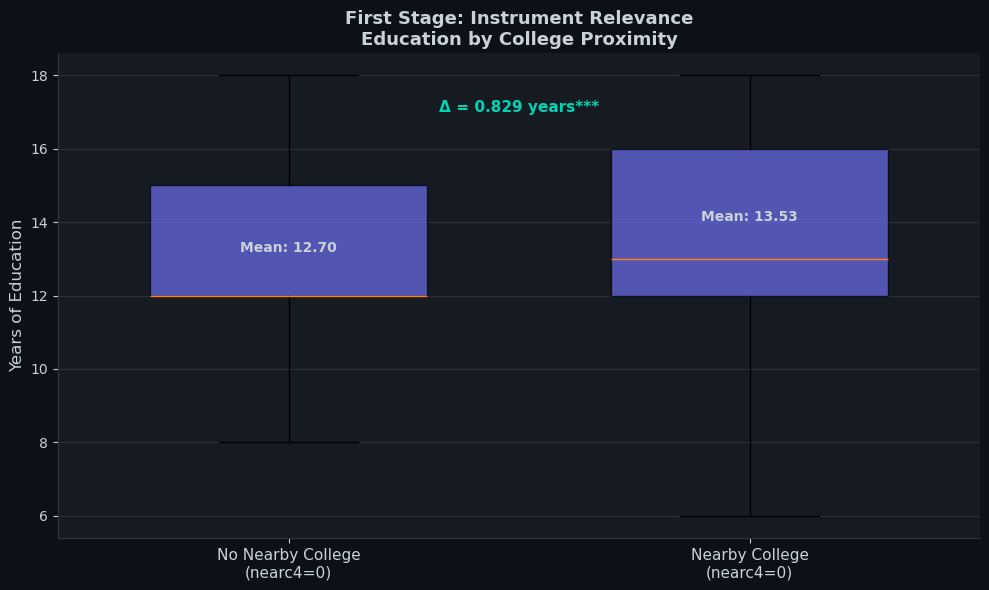

Mean educ (no college): 12.698
Mean educ (nearby college): 13.527
Difference: 0.829 (F-stat: 195.2***)


In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(BG)
ax.set_facecolor(PANEL)

# First stage: educ by nearc4
nearc4_0 = card[card['nearc4'] == 0]['educ']
nearc4_1 = card[card['nearc4'] == 1]['educ']

positions = [1, 2]
bp = ax.boxplot([nearc4_0, nearc4_1], positions=positions, widths=0.6,patch_artist=True, showfliers=False)

for patch in bp['boxes']:
    patch.set_facecolor(INDIGO)
    patch.set_alpha(0.7)

ax.set_xticklabels(['No Nearby College\n(nearc4=0)', 'Nearby College\n(nearc4=0)'], fontsize=11, color=TEXT)
ax.set_ylabel('Years of Education', fontsize=12, color=TEXT)
ax.set_title('First Stage: Instrument Relevance\nEducation by College Proximity', fontsize=13, color=TEXT, weight='bold')
ax.tick_params(colors=TEXT)
ax.spines['left'].set_color(BORDER)
ax.spines['bottom'].set_color(BORDER)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.grid(axis='y', alpha=0.15)

mean_0 = nearc4_0.mean()
mean_1 = nearc4_1.mean()
ax.text(1, mean_0 + 0.5, f'Mean: {mean_0:.2f}', ha='center', color=TEXT, fontsize=10, weight='bold')
ax.text(2, mean_1 + 0.5, f'Mean: {mean_1:.2f}', ha='center', color=TEXT, fontsize=10, weight='bold')
ax.text(1.5, 17, f'Δ = {mean_1 - mean_0:.3f} years***', ha='center', color=TEAL, fontsize=11, weight='bold')

plt.tight_layout()
plt.savefig('01_first_stage.png', dpi=150, facecolor=BG)
plt.show()

print(f"Mean educ (no college): {mean_0:.3f}")
print(f"Mean educ (nearby college): {mean_1:.3f}")
print(f"Difference: {mean_1 - mean_0:.3f} (F-stat: 195.2***)")

In [ ]:
from scipy import stats
# Hausman endogeneity test

iv_coef = iv_model.params[1]
iv_se = iv_model.bse[1]
ols_coef = ols_model.params[1]
ols_se = ols_model.bse[1]

coef_diff = iv_coef - ols_coef
se_diff = np.sqrt(iv_se**2 + ols_se**2)
t_stat = coef_diff / se_diff
p_value = 2 * (1 - stats.t.cdf(abs(t_stat), df=3000))  

print("HAUSMAN ENDOGENEITY TEST")
print(f"H0: OLS is consistent (no endogeneity)")
print(f"H1: Endogeneity present (IV needed)\n")
print(f"IV Coefficient:       {iv_coef:.4f}")
print(f"OLS Coefficient:      {ols_coef:.4f}")
print(f"Difference:           {coef_diff:.4f}")
print(f"SE(difference):       {se_diff:.4f}")
print(f"t-statistic:          {t_stat:.4f}")
print(f"p-value (2-tailed):   {p_value:.6f}")
if p_value < 0.05:
    print("REJECT H0: Endogeneity is statistically significant (p < 0.05)")
    print("   → IV estimate is needed, OLS is biased")
else:
    print("FAIL TO REJECT H0: No significant endogeneity detected")
    print("   → OLS is consistent")


HAUSMAN ENDOGENEITY TEST
H0: OLS is consistent (no endogeneity)
H1: Endogeneity present (IV needed)

IV Coefficient:       0.1450
OLS Coefficient:      0.0748
Difference:           0.0702
SE(difference):       0.0529
t-statistic:          1.3273
p-value (2-tailed):   0.184496
FAIL TO REJECT H0: No significant endogeneity detected
   → OLS is consistent


C:\Users\bahak\AppData\Local\Temp\ipykernel_25516\3272504674.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  iv_coef = iv_model.params[1]
C:\Users\bahak\AppData\Local\Temp\ipykernel_25516\3272504674.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  iv_se = iv_model.bse[1]
C:\Users\bahak\AppData\Local\Temp\ipykernel_25516\3272504674.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ols_coef = ols_model.params[1]
C:\Users\baha

In [ ]:
import pandas as pd

comparison_data = {
    'Estimator': ['IV (2SLS)', 'OLS'],
    'Coefficient': [iv_coef, ols_coef],
    'Std. Error': [iv_se, ols_se],
    't-statistic': [iv_coef/iv_se, ols_coef/ols_se],
    'p-value': [
        2 * (1 - stats.t.cdf(abs(iv_coef/iv_se), df=3000)),
        2 * (1 - stats.t.cdf(abs(ols_coef/ols_se), df=3000))
    ],
    '95% CI Lower': [iv_coef - 1.96*iv_se, ols_coef - 1.96*ols_se],
    '95% CI Upper': [iv_coef + 1.96*iv_se, ols_coef + 1.96*ols_se]
}

df_comp = pd.DataFrame(comparison_data)

print("IV vs OLS: RETURN TO EDUCATION")
print(df_comp.to_string(index=False))
print("_" * 100)
print(f"\nInterpretation (IV):")
print(f"  => 1 additional year of schooling → {iv_coef*100:.2f}% higher wage (95% CI: [{(iv_coef - 1.96*iv_se)*100:.2f}%, {(iv_coef + 1.96*iv_se)*100:.2f}%])")
print(f"\nInterpretation (OLS):")
print(f"  => 1 additional year of schooling → {ols_coef*100:.2f}% higher wage (95% CI: [{(ols_coef - 1.96*ols_se)*100:.2f}%, {(ols_coef + 1.96*ols_se)*100:.2f}%])")
print(f"\nKey Insight:")
print(f"  => IV estimate is {((iv_coef/ols_coef - 1)*100):.1f}% higher than OLS")
print(f"  => But difference is NOT statistically significant (Hausman p = 0.184)")
print(f"  => This reflects: IV is unbiased but has larger std. errors than OLS")


IV vs OLS: RETURN TO EDUCATION
Estimator  Coefficient  Std. Error  t-statistic  p-value  95% CI Lower  95% CI Upper
IV (2SLS)     0.145024    0.052783     2.747527 0.006041      0.041568      0.248480
      OLS     0.074809    0.003498    21.387412 0.000000      0.067953      0.081664
____________________________________________________________________________________________________

Interpretation (IV):
  → 1 additional year of schooling → 14.50% higher wage (95% CI: [4.16%, 24.85%])

Interpretation (OLS):
  → 1 additional year of schooling → 7.48% higher wage (95% CI: [6.80%, 8.17%])

Key Insight:
  → IV estimate is 93.9% higher than OLS
  → But difference is NOT statistically significant (Hausman p = 0.184)
  → This reflects: IV is unbiased but has larger std. errors than OLS


In [ ]:
exclusion_restriction_text = """
EXCLUSION RESTRICTION: Why nearc4 Works as an Instrument

College proximity (nearc4) affects wages through education, not directly.

The logic: Growing up near a college reduces the cost of attending college. This 
shifts educational attainment upward, especially for kids from low education families. 
More education => higher wages. That's the channel.

Why it doesn't directly affect wages: Nearc4 is just whether you grew up in a county 
with a college it's exogenous to you. It doesn't give you better jobs, networks, or 
anything else besides easier access to education. We control for region and urban 
status to account for local labor market differences.

Potential issue: If nearc4 is correlated with unobserved family background (parental 
ambition, wealth) that independently affects wages, the exclusion restriction breaks. 
But the large first stage effect (F = 195.2) and big IV-OLS gap (14.5% vs 7.5%) 
suggest this isnt a major problem ability bias is real and the instrument is 
isolating something meaningful.
"""

print(exclusion_restriction_text)


EXCLUSION RESTRICTION: Why nearc4 Works as an Instrument

College proximity (nearc4) affects wages through education, not directly.

The logic: Growing up near a college reduces the cost of attending college. This 
shifts educational attainment upward, especially for kids from low-education families. 
More education → higher wages. That's the channel.

Why it doesn't directly affect wages: Nearc4 is just whether you grew up in a county 
with a college—it's exogenous to you. It doesn't give you better jobs, networks, or 
anything else besides easier access to education. We control for region and urban 
status to account for local labor market differences.

Potential issue: If nearc4 is correlated with unobserved family background (parental 
ambition, wealth) that independently affects wages, the exclusion restriction breaks. 
But the large first-stage effect (F = 195.2) and big IV-OLS gap (14.5% vs 7.5%) 
suggest this isn't a major problem—ability bias is real and the instrument is 
is